# **Soliton Solutions to the Kadomtsev–Petviashvili (KP) equation**

Here we present a brief example of how the code is used to solve the KP equation for one- and two-soliton solutions using physics-informed neural networks.

**Setup:**

In [1]:
import torch

import sys
from pathlib import Path

# add parent directory to path
sys.path.append(str(Path.cwd().parent))

from models import KP

Check GPU availability:

In [2]:
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

CUDA available: True


## **One soliton**

Configure and train a model for a single line soliton:

In [4]:
model = KP(
    n_hidden_layers=5,
    n_neurons_per_layer=4,
    k=(0.5,),
    P=(2/3,),
    t_lims=(-10, 10),
    seed=42,
    verbose=True,
)

Using device: cuda
 Solving KP-II equation with 1 solitons.


Train the model:

In [5]:
model.train(n_collocation=50000, n_initial=10000, n_boundary=500)

Training domain setup complete:
  Collocation points: 50000
  Initial points: 10000
  Boundary points: 62500


/home/karnav/anaconda3/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/conda/conda-bld/pytorch_1729647429097/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam - Epoch 0/1000, Total Loss: 7.447822e+00
Adam - Epoch 100/1000, Total Loss: 2.852197e-01
Adam - Epoch 200/1000, Total Loss: 1.964246e-02
Adam - Epoch 300/1000, Total Loss: 1.163158e-02
Adam - Epoch 400/1000, Total Loss: 9.335283e-03
Adam - Epoch 500/1000, Total Loss: 8.039773e-03
Adam - Epoch 600/1000, Total Loss: 7.139191e-03
Adam - Epoch 700/1000, Total Loss: 6.447160e-03
Adam - Epoch 800/1000, Total Loss: 5.891059e-03
Adam - Epoch 900/1000, Total Loss: 5.431024e-03
Adam - Epoch 999/1000, Total Loss: 5.045599e-03

Starting L-BFGS optimization...
L-BFGS - Iteration 100, Total Loss: 6.864915e-04
L-BFGS - Iteration 200, Total Loss: 7.207263e-06
L-BFGS - Iteration 300, Total Loss: 7.068959e-07
L-BFGS - Iteration 400, Total Loss: 3.476567e-07
L-BFGS complete, Final Loss: 8.835710e-08


Test and visualize:

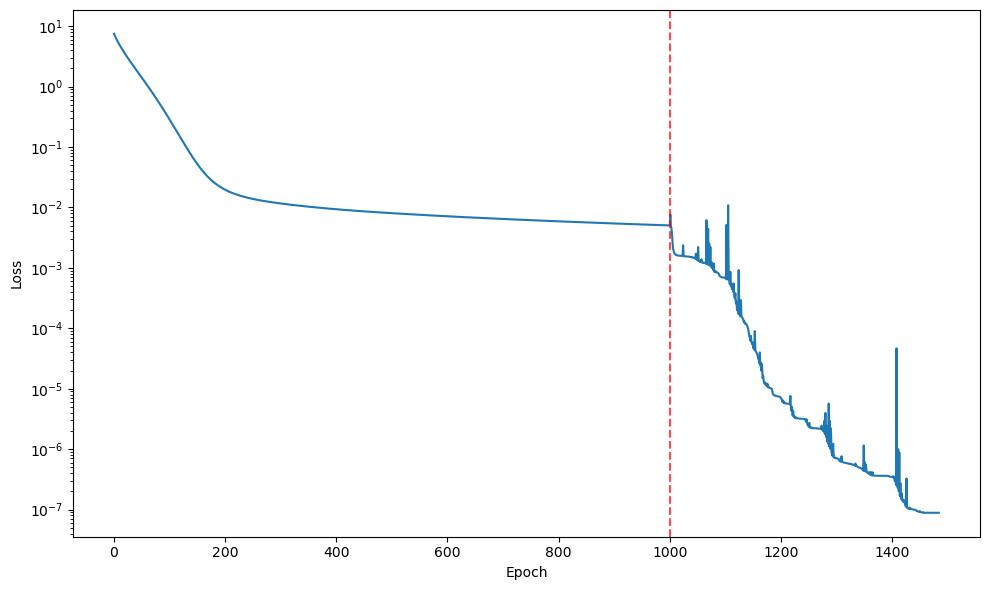

In [6]:
model.plot_losses()

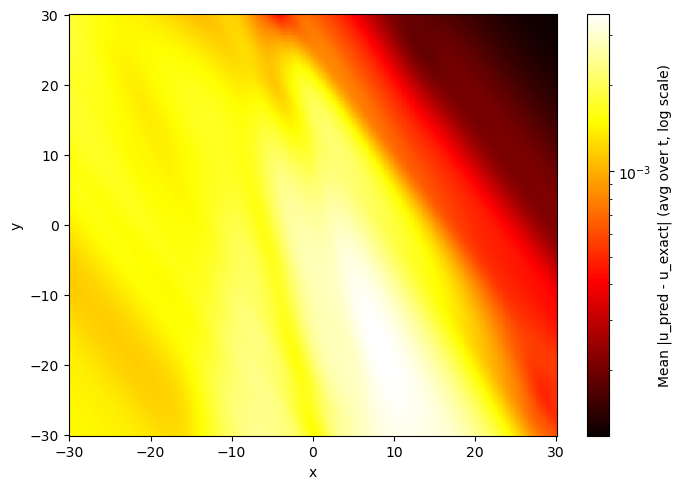

0.0014416102785617113

In [8]:
model.test(plot_heatmap=True, error_type="absolute-normalized")

Note that for the KP case, the heatmap shows the mean  

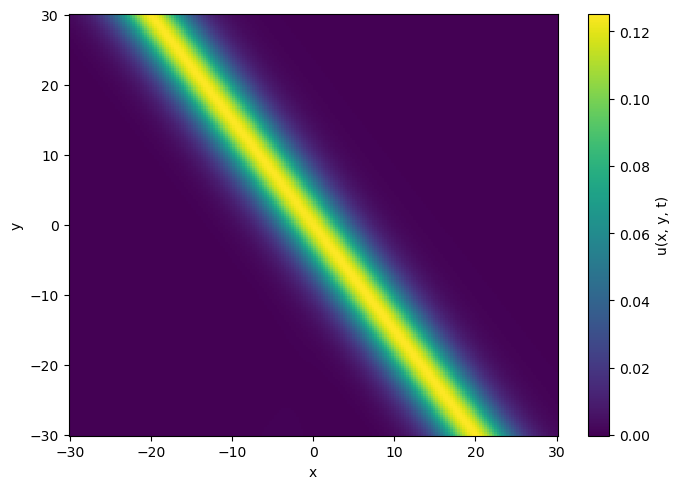

In [9]:
model.plot_heatmap(t_value=0, which='predicted')

## **x-junction**

Configure and train for two solitons colliding head-on (x-junction):

In [3]:
model_x = KP(
    n_hidden_layers=8,
    n_neurons_per_layer=32,
    k=(0.5, 0.5),
    P=(-2/3, 2/3),
    t_lims=(-20, 20),
    seed=42,
    verbose=True,
)

model_x.train(n_collocation=50000, n_initial=10000, n_boundary=500)

Using device: cuda
 Solving KP-II equation with 2 solitons.
Training domain setup complete:
  Collocation points: 50000
  Initial points: 10000
  Boundary points: 62500


/home/karnav/anaconda3/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/conda/conda-bld/pytorch_1729647429097/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam - Epoch 0/1000, Total Loss: 5.192339e-01
Adam - Epoch 100/1000, Total Loss: 2.123936e-03
Adam - Epoch 200/1000, Total Loss: 1.873065e-03
Adam - Epoch 300/1000, Total Loss: 1.711402e-03
Adam - Epoch 400/1000, Total Loss: 1.558196e-03
Adam - Epoch 500/1000, Total Loss: 1.389869e-03
Adam - Epoch 600/1000, Total Loss: 1.180613e-03
Adam - Epoch 700/1000, Total Loss: 9.340030e-04
Adam - Epoch 800/1000, Total Loss: 7.241602e-04
Adam - Epoch 900/1000, Total Loss: 5.917919e-04
Adam - Epoch 999/1000, Total Loss: 5.006973e-04

Starting L-BFGS optimization...
L-BFGS - Iteration 100, Total Loss: 8.605811e-05
L-BFGS - Iteration 200, Total Loss: 3.285064e-05
L-BFGS - Iteration 300, Total Loss: 2.043354e-05
L-BFGS - Iteration 400, Total Loss: 1.475445e-05
L-BFGS - Iteration 500, Total Loss: 1.196555e-05
L-BFGS - Iteration 600, Total Loss: 9.152100e-06
L-BFGS - Iteration 700, Total Loss: 7.274706e-06
L-BFGS - Iteration 800, Total Loss: 5.862996e-06
L-BFGS - Iteration 900, Total Loss: 4.939341e-06


Test and visualize:

In [4]:
model_x.test()

absolute-normalized error metrics:
Mean: 1.603414e-03
Maximum: 1.545493e-02


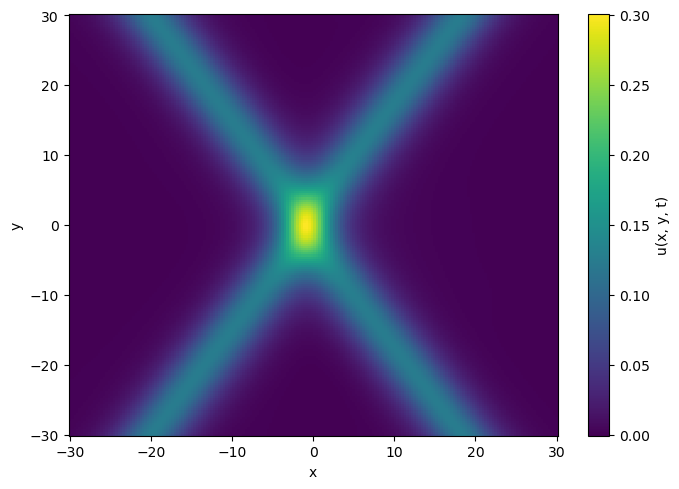

In [5]:
model_x.plot_heatmap(t_value=0, which='predicted')

## **x-long interaction**

Configure and train for two solitons with extended x-interaction:

In [10]:
model_xlong = KP(
    n_hidden_layers=8,
    n_neurons_per_layer=32,
    k=(0.5, 0.5),
    P=(-1/4-1e-2, 3/4),
    t_lims=(-20, 20),
    seed=42,
    verbose=False,
)

model_xlong.train(n_collocation=50000, n_initial=10000, n_boundary=500)

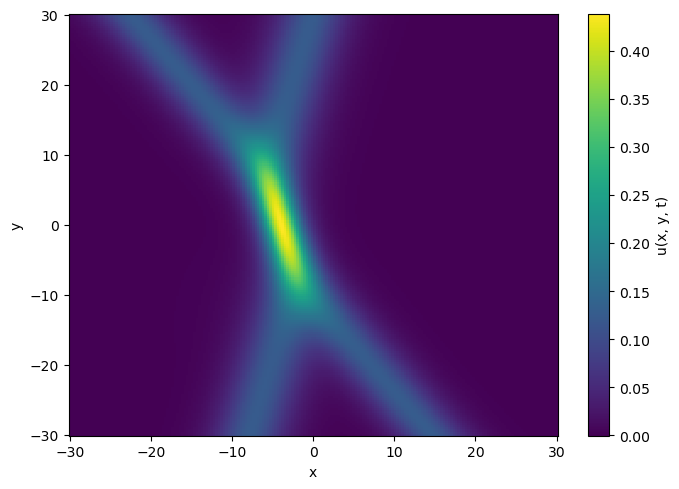

In [11]:
model_xlong.plot_heatmap(t_value=0, which='predicted')

## **y-junction**

In [7]:
model_y = KP(
    n_hidden_layers=8,
    n_neurons_per_layer=32,
    k=(0.5, 1.0),
    P=(3/4, 1/4),
    t_lims=(-20, 20),
    seed=42,
    verbose=True,
)

model_y.train(n_collocation=50000, n_initial=10000, n_boundary=500, lbfgs_epochs=100000)

Using device: cuda
 Solving KP-II equation with 2 solitons.
Training domain setup complete:
  Collocation points: 50000
  Initial points: 10000
  Boundary points: 62500
Adam - Epoch 0/1000, Total Loss: 5.464154e-01
Adam - Epoch 100/1000, Total Loss: 3.877361e-03
Adam - Epoch 200/1000, Total Loss: 3.266158e-03
Adam - Epoch 300/1000, Total Loss: 2.823733e-03
Adam - Epoch 400/1000, Total Loss: 2.472837e-03
Adam - Epoch 500/1000, Total Loss: 2.150608e-03
Adam - Epoch 600/1000, Total Loss: 1.724427e-03
Adam - Epoch 700/1000, Total Loss: 1.345541e-03
Adam - Epoch 800/1000, Total Loss: 1.122662e-03
Adam - Epoch 900/1000, Total Loss: 9.752390e-04
Adam - Epoch 999/1000, Total Loss: 8.648240e-04

Starting L-BFGS optimization...
L-BFGS - Iteration 100, Total Loss: 4.527359e-04
L-BFGS - Iteration 200, Total Loss: 2.870820e-04
L-BFGS - Iteration 300, Total Loss: 1.520007e-04
L-BFGS - Iteration 400, Total Loss: 8.986829e-05
L-BFGS - Iteration 500, Total Loss: 5.564865e-05
L-BFGS - Iteration 600, Tot

In [8]:
model_y.test()

absolute-normalized error metrics:
Mean: 7.738108e-04
Maximum: 1.693042e-02


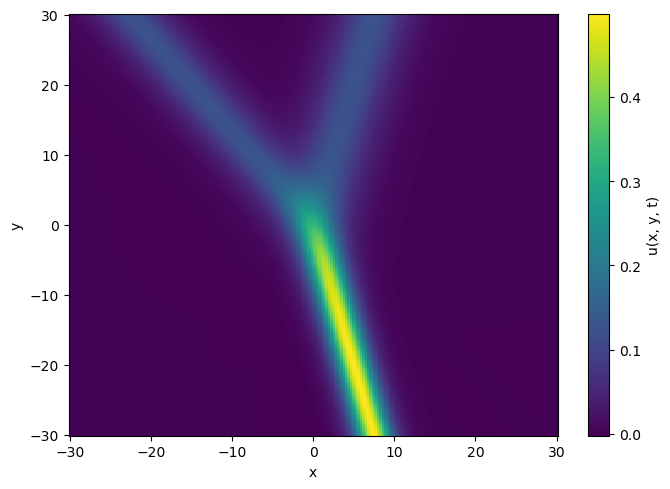

In [9]:
model_y.plot_heatmap(t_value=0, which='predicted')

## **Saving results**

Save results using:

```python
model.save_results("results/model.json")
```

The saved JSON contains the full solution, domain, and configuration.